In [ ]:
from typing import List, TypedDict ,Literal
from pydantic import BaseModel, Field
from dotenv import load_dotenv
import os

from langchain_community.document_loaders import TextLoader
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_graphraphroq import ChatGroq
from langchain_google_genai import ChatGoogleGenerativeAI


from langgraph.graph import StateGraph, START, END




In [4]:
load_dotenv()

python-dotenv could not parse statement starting at line 8
python-dotenv could not parse statement starting at line 12


True

In [5]:
 #=========================
# Embeddings + Vector Store (Chroma)
# =========================
CHROMA_PATH = "chroma_db"
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

# Check if DB exists, otherwise create it
if os.path.exists(CHROMA_PATH):
    print("--- LOADING EXISTING CHROMA DB ---")
    vectorstore = Chroma(
        persist_directory=CHROMA_PATH, 
        embedding_function=embeddings
    )
else:
    print("--- CREATING NEW CHROMA DB ---")
    docs = TextLoader("nadra_info.txt").load()
    chunks = RecursiveCharacterTextSplitter(
        chunk_size=600,
        chunk_overlap=150
    ).split_documents(docs)
    
    vectorstore = Chroma.from_documents(
        documents=chunks,
        embedding=embeddings,
        persist_directory=CHROMA_PATH
    )

retriever = vectorstore.as_retriever(search_kwargs={"k": 3})


python-dotenv could not parse statement starting at line 8
python-dotenv could not parse statement starting at line 12


--- LOADING EXISTING CHROMA DB ---


In [6]:
#=========================
# LLM
# =========================

llm = ChatGroq(model="llama-3.3-70b-versatile" ,api_key=os.getenv("GROQ_API_KEY"))

In [8]:

# =========================
# Graph State
# =========================
class MyState(TypedDict):
    question: str
    need_retrieval: bool
    docs: List[Document]
    answer: str


In [ ]:

# =========================
# Structured Output Model
# =========================
class RetrievalDecision(BaseModel):
    need_retrieval: bool = Field(
        ...,
        description="Whether the question needs retrieval or not"
    )



# -----------------------------
# 4) Relevance filter (strict)
# -----------------------------
class RelevanceDecision(BaseModel):
    is_relevant: bool = Field(
        ...,
        description="True ONLY if the document contains info that can directly answer the question."
    )

In [ ]:

# =========================
# Prompt: Decide Retrieval
# =========================
decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are an expert router. Determine if the question is about NADRA documents/rules or general knowledge.\n"
            "Return JSON: {{'need_retrieval': boolean}}\n\n"
            "Guidelines:\n"
            "- need_retrieval=True: Specific facts about NADRA, CNIC, Juvenile cards, or POC.\n"
            "- need_retrieval=False: General knowledge (e.g., 'What is Machine Learning?'), greetings, or math.\n"
            "- If unsure, choose True."
        ),
        ("human", "Question: {question}"),
    ]
)

decision_llm = llm.with_structured_output(RetrievalDecision)
relevance_llm = llm.with_structured_output(RelevanceDecision)

# =========================
# Prompt: Direct Answer
# =========================
direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the question using only your general knowledge.\n"
            "If you are unsure, say 'I don't know based on my general knowledge.'"
        ),
        ("human", "{question}"),
    ]
)

# =========================
# Prompt: Answer with Retrieved Docs
# =========================
retrieval_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the user's question using ONLY the provided context.\n"
            "If not in context, say: 'I could not find the answer in the provided document.'"
        ),
        (
            "human",
            "Question: {question}\n\n"
            "Context:\n{context}"
        ),
    ]
)



# is the document relevant to the question 
is_relevant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging document relevance at a TOPIC level.\n"
            "Return JSON matching the schema.\n\n"
            "A document is relevant if it discusses the same entity or topic area as the question.\n"
            "It does NOT need to contain the exact answer.\n\n"
            "Examples:\n"
            "- HR policies are relevant to questions about notice period, probation, termination, benefits.\n"
            "- Pricing documents are relevant to questions about refunds, trials, billing terms.\n"
            "- Company profile is relevant to questions about leadership, culture, size, or strategy.\n\n"
            "Do NOT decide whether the document fully answers the question.\n"
            "That will be checked later by IsSUP.\n"
            "When unsure, return is_relevant=true."
        ),
        ("human", "Question:\n{question}\n\nDocument:\n{document}"),
    ]
)




In [ ]:

# =========================
# Nodes
# =========================
def decide_retrieval(state: MyState):
    decision: RetrievalDecision = decision_llm.invoke(
        decide_retrieval_prompt.format_messages(question=state["question"])
    )
    return {"need_retrieval": decision.need_retrieval}



def generate_direct(state: MyState):
    ans = llm.invoke(direct_generation_prompt.format_messages(question=state["question"]))
    return {"answer": ans.content}



def retrieve(state: MyState):
    retrieved_docs = retriever.invoke(state["question"])
    return {"docs": retrieved_docs}


def is_relevant(state: MyState):
    relevant_docs: List[Document] = []
    for doc in state.get("docs", []):
        decision: RelevanceDecision = relevance_llm.invoke(
            is_relevant_prompt.format_messages(
                question=state["question"],
                document=doc.page_content,
            )
        )
        if decision.is_relevant:
            relevant_docs.append(doc)
    return {"relevant_docs": relevant_docs}



def generate_with_retrieval(state: MyState):
    context = "\n\n".join(doc.page_content for doc in state["docs"])
    ans = llm.invoke(
        retrieval_generation_prompt.format_messages(
            question=state["question"],
            context=context
        )
    )
    return {"answer": ans.content}



# =========================
# Router Edge
# =========================
def route_decider(state: MyState):
    return "retrieve" if state["need_retrieval"] else "generate_direct"


def route_after_relevance(state: MyState) -> Literal["generate_from_context", "no_answer_found"]:
    if state.get("relevant_docs") and len(state["relevant_docs"]) > 0:
        return "generate_from_context"
    return "no_answer_found"




In [ ]:
# -----------------------------
# 5) Generate from context
# -----------------------------
rag_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a business rag chatbot.\n\n"
            "You will receive a CONTEXT block from internal company documents.\n"
            "Task:\n"
            "Answer the question based on the context"
            "Dont mention that you are getting a context in your answer"
        ),
        ("human", "Question:\n{question}\n\nContext:\n{context}"),
    ]
)



def generate_from_context(state: MyState):
    context = "\n\n---\n\n".join([d.page_content for d in state.get("relevant_docs", [])]).strip()
    if not context:
        return {"answer": "No answer found.", "context": ""}
    out = llm.invoke(
        rag_generation_prompt.format_messages(question=state["question"], context=context)
    )
    return {"answer": out.content, "context": context}



def no_answer_found(state: MyState):
    return {"answer": "No answer found.", "context": ""}

In [ ]:
# -----------------------------
# 6) IsSUP verify + revise loop
# -----------------------------

# basically checking whether AI generated answer is supported by the retrieved context or not

class IsSUPDecision(BaseModel):
    issup: Literal["fully_supported", "partially_supported", "no_support"]
    evidence: List[str] = Field(default_factory=list)

issup_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are verifying whether the ANSWER is supported by the CONTEXT.\n"
            "Return JSON with keys: issup, evidence.\n"
            "issup must be one of: fully_supported, partially_supported, no_support.\n\n"
            "How to decide issup:\n"
            "- fully_supported:\n"
            "  Every meaningful claim is explicitly supported by CONTEXT, and the ANSWER does NOT introduce\n"
            "  any qualitative/interpretive words that are not present in CONTEXT.\n"
            "  (Examples of disallowed words unless present in CONTEXT: culture, generous, robust, designed to,\n"
            "  supports professional development, best-in-class, employee-first, etc.)\n\n"
            "- partially_supported:\n"
            "  The core facts are supported, BUT the ANSWER includes ANY abstraction, interpretation, or qualitative\n"
            "  phrasing not explicitly stated in CONTEXT (e.g., calling policies 'culture', saying leave is 'generous',\n"
            "  or inferring outcomes like 'supports professional development').\n\n"
            "- no_support:\n"
            "  The key claims are not supported by CONTEXT.\n\n"
            "Rules:\n"
            "- Be strict: if you see ANY unsupported qualitative/interpretive phrasing, choose partially_supported.\n"
            "- If the answer is mostly unrelated to the question or unsupported, choose no_support.\n"
            "- Evidence: include up to 3 short direct quotes from CONTEXT that support the supported parts.\n"
            "- Do not use outside knowledge."
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Answer:\n{answer}\n\n"
            "Context:\n{context}\n"
        ),
    ]
)



issup_llm = llm.with_structured_output(IsSUPDecision)

def is_sup(state: MyState):
    decision: IsSUPDecision = issup_llm.invoke(
        issup_prompt.format_messages(
            question=state["question"],
            answer=state.get("answer", ""),
            context=state.get("context", ""),
        )
    )
    return {"issup": decision.issup, "evidence": decision.evidence}


MAX_RETRIES = 10

def route_after_issup(state: MyState) -> Literal["accept_answer", "revise_answer"]:
    # fully supported -> move forward to IsUSE (via "accept_answer" label)
    if state.get("issup") == "fully_supported":
        return "accept_answer"

    if state.get("retries", 0) >= MAX_RETRIES:
        return "accept_answer"  # will go to is_use, then likely not_useful -> no_answer_found

    return "revise_answer"

In [ ]:
def accept_answer(state: MyState):
    return {}

revise_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a STRICT reviser.\n\n"
            "You must output based on the following format:\n\n"
            "FORMAT (quote-only answer):\n"
            "- <direct quote from the CONTEXT>\n"
            "- <direct quote from the CONTEXT>\n\n"
            "Rules:\n"
            "- Use ONLY the CONTEXT.\n"
            "- Do NOT add any new words besides bullet dashes and the quotes themselves.\n"
            "- Do NOT explain anything.\n"
            "- Do NOT say 'context', 'not mentioned', 'does not mention', 'not provided', etc.\n"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Current Answer:\n{answer}\n\n"
            "CONTEXT:\n{context}"
        ),
    ]
)



def revise_answer(state: MyState):
    out = llm.invoke(
        revise_prompt.format_messages(
            question=state["question"],
            answer=state.get("answer", ""),
            context=state.get("context", ""),
        )
    )
    return {
        "answer": out.content,
        "retries": state.get("retries", 0) + 1,  # ✅ increment
    }

In [ ]:
class RewriteDecision(BaseModel):
    retrieval_query: str = Field(
        ...,
        description="Rewritten query optimized for vector retrieval against internal company PDFs."
    )

rewrite_for_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Rewrite the user's QUESTION into a query optimized for vector retrieval over INTERNAL company PDFs.\n\n"
            "Rules:\n"
            "- Keep it short (6–16 words).\n"
            "- Preserve key entities (e.g., NexaAI, plan names).\n"
            "- Add 2–5 high-signal keywords that likely appear in policy/pricing docs.\n"
            "- Remove filler words.\n"
            "- Do NOT answer the question.\n"
            "- Output JSON with key: retrieval_query\n\n"
            "Examples:\n"
            "Q: 'Do NexaAI plans include a free trial?'\n"
            "-> {{'retrieval_query': 'NexaAI free trial duration trial period plans'}}\n\n"
            "Q: 'What is NexaAI refund policy?'\n"
            "-> {{'retrieval_query': 'NexaAI refund policy cancellation refund timeline charges'}}"
        ),
        (
            "human",
            "QUESTION:\n{question}\n\n"
            "Previous retrieval query:\n{retrieval_query}\n\n"
            "Answer (if any):\n{answer}"
        ),
    ]
)



rewrite_llm = llm.with_structured_output(RewriteDecision)

def rewrite_question(state: MyState):
    decision: RewriteDecision = rewrite_llm.invoke(
        rewrite_for_retrieval_prompt.format_messages(
            question=state["question"],
            retrieval_query=state.get("retrieval_query", ""),
            answer=state.get("answer", ""),
        )
    )

    return {
        "retrieval_query": decision.retrieval_query,
        "rewrite_tries": state.get("rewrite_tries", 0) + 1,
        # ✅ optional: reset these so next pass is clean
        "docs": [],
        "relevant_docs": [],
        "context": "",
    }

In [ ]:
# Build graph (UPDATED: IsUSE -> if not useful -> rewrite -> retrieve; else END)
# -----------------------------
graph = StateGraph(MyState)

# --------------------
# Nodes
# --------------------

graph.add_node("decide_retrieval", decide_retrieval)
graph.add_node("generate_direct", generate_direct)
graph.add_node("retrieve", retrieve)

graph.add_node("is_relevant", is_relevant)
graph.add_node("generate_from_context", generate_from_context)
graph.add_node("no_answer_found", no_answer_found)

# IsSUP + revise loop
graph.add_node("is_sup", is_sup)
graph.add_node("revise_answer", revise_answer)

# IsUSE
graph.add_node("is_use", is_use)

# ✅ NEW: rewrite question for better retrieval
graph.add_node("rewrite_question", rewrite_question)

# --------------------
# Edges
# --------------------
graph.add_edge(START, "decide_retrieval")

graph.add_conditional_edges(
    "decide_retrieval",
    route_after_decide,
    {"generate_direct": "generate_direct", "retrieve": "retrieve"},
)

graph.add_edge("generate_direct", END)

# Retrieve -> relevance -> (generate | no_answer_found)
graph.add_edge("retrieve", "is_relevant")

graph.add_conditional_edges(
    "is_relevant",
    route_after_relevance,
    {
        "generate_from_context": "generate_from_context",
        "no_answer_found": "no_answer_found",
    },
)

graph.add_edge("no_answer_found", END)

# --------------------
# Generate -> IsSUP -> (IsUSE | revise) loop
# --------------------
graph.add_edge("generate_from_context", "is_sup")

graph.add_conditional_edges(
    "is_sup",
    route_after_issup,
    {
        "accept_answer": "is_use",      # fully_supported (or max retries) -> go to IsUSE
        "revise_answer": "revise_answer",
    },
)

graph.add_edge("revise_answer", "is_sup")  # 🔁 loop back to IsSUP

# --------------------
# IsUSE routing
#   - useful -> END
#   - not_useful -> rewrite_question -> retrieve (try again)
#   - give up -> no_answer_found -> END
# --------------------
graph.add_conditional_edges(
    "is_use",
    route_after_isuse,
    {
        "END": END,
        "rewrite_question": "rewrite_question",
        "no_answer_found": "no_answer_found",
    },
)

# rewrite -> retrieve -> relevance -> ...
graph.add_edge("rewrite_question", "retrieve")

app = graph.compile()
app


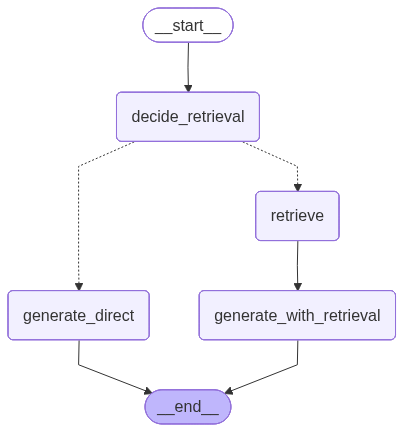

In [14]:
app

In [13]:

# =========================
# Run Example
# =========================
if __name__ == "__main__":
    question = input("Ask your question: ")

    result = app.invoke({
        "question": question,
        "need_retrieval": False,
        "docs": [],
        "answer": ""
    })

    print("\nFinal Answer:\n")
    print(result["answer"])


Final Answer:

There are offices in the following locations in Hyderabad:

1. Heeraabad, near Liberty Market
2. Qasimabad, at Labour Court, Naseem Nagar
3. State Life Building, Thandi Sarak, UC-1, Tehsil Latifabad
4. Big NRC Hyderabad, Latifabad, Neha Tower, Plot #7, Block E, Airport Road
5. Pakka Qila, near Home Stade Hall
6. Tando Jam, at UC Moosa Khatyan Building, Opposite PTCL Office, Naka Stop, Tando Jam City

Note that some of these offices have the same name (e.g. State Life Building, Big NRC Hyderabad) but they are listed separately as they have different shifts (morning and evening).
